In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import json
import warnings

# Set display options
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set plot style
sns.set_style("whitegrid")
sns.set_palette("coolwarm")
print("✓ All libraries successfully imported")

✓ All libraries successfully imported


In [2]:
def load_and_prepare_data(gp2024_file, gp2025_file):
    
    print(f"Loading data...")
    print(f"  2024 data file: {os.path.relpath(gp2024_file)}")
    print(f"  2025 data file: {os.path.relpath(gp2024_file)}")
    
    # Read CSV files
    gp2024_df = pd.read_csv(gp2024_file)
    gp2025_df = pd.read_csv(gp2025_file)
    
    # Add season labels
    gp2024_df['Season'] = 'Grand Prix 2024'
    gp2025_df['Season'] = 'Grand Prix 2025'
    
    # Merge data
    combined_df = pd.concat([gp2024_df, gp2025_df], ignore_index=True)
    
    print(f"✓ Data loading completed")
    print(f"  2024 data rows: {len(gp2024_df)}")
    print(f"  2025 data rows: {len(gp2025_df)}")
    print(f"  Total rows after merging: {len(combined_df)}")
    
    return combined_df

In [3]:
def preprocess_arrival_duration(df, assume_seconds=True):
    
    if 'arrivalDuration' in df.columns:
        # 1. Check arrivalDuration data
        original_len = len(df)
        
        # Calculate statistics
        mean_val = df['arrivalDuration'].mean()
        median_val = df['arrivalDuration'].median()
        min_val = df['arrivalDuration'].min()
        max_val = df['arrivalDuration'].max()
        
        # Process data according to user settings
        if assume_seconds:
            df['arrivalDuration_seconds'] = df['arrivalDuration']
            unit_label = 'seconds'
        else:
            if mean_val < 100:
                df['arrivalDuration_seconds'] = df['arrivalDuration'] * 60
                unit_label = 'seconds (converted from minutes)'
            else:
                df['arrivalDuration_seconds'] = df['arrivalDuration']
                unit_label = 'seconds'
        
        # Calculate statistics after processing
        mean_sec = df['arrivalDuration_seconds'].mean()
        median_sec = df['arrivalDuration_seconds'].median()
        min_sec = df['arrivalDuration_seconds'].min()
        max_sec = df['arrivalDuration_seconds'].max()
        
        # Remove extreme outliers (using IQR method)
        Q1 = df['arrivalDuration_seconds'].quantile(0.25)
        Q3 = df['arrivalDuration_seconds'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        outliers = df[(df['arrivalDuration_seconds'] < lower_bound) | 
                      (df['arrivalDuration_seconds'] > upper_bound)]
        print(f"ArrivalDuration outliers: {len(outliers)} / {original_len} ({(len(outliers)/original_len*100):.2f}%)")
        
        # Display data distribution information
        print(f"\nData distribution (in seconds):")
        print(f"  25th percentile: {Q1:.2f} seconds ({Q1/60:.2f} minutes)")
        print(f"  75th percentile: {Q3:.2f} seconds ({Q3/60:.2f} minutes)")
        print(f"  IQR: {IQR:.2f} seconds ({IQR/60:.2f} minutes)")
        
        return 'arrivalDuration_seconds', unit_label
    return None, None

In [4]:
def create_multiple_violin_plots(df, features_config, output_dir=".", 
                                 violin_rest_color='#8787b7', violin_q1_q3_color='#db2836'):

    os.makedirs(output_dir, exist_ok=True)
    
    # Determine subplot layout
    n_features = len(features_config)
    n_rows = (n_features + 1) // 2
    n_cols = 2 if n_features > 1 else 1
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    
    # Handle axes for single row cases
    if n_rows == 1 and n_cols > 1:
        axes = axes.reshape(1, -1)
    elif n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    
    # Set colors
    color_rest = violin_rest_color
    color_q1_q3 = violin_q1_q3_color
    
    # Process each feature
    for idx, (feature_col, subplot_title, y_label) in enumerate(features_config):
        # Calculate subplot position
        row = idx // n_cols
        col = idx % n_cols
        
        ax = axes[row, col]
        
        # Check if feature column exists
        if feature_col not in df.columns:
            print(f"Warning: Column '{feature_col}' not found. Skipping this plot.")
            ax.text(0.5, 0.5, f"Column '{feature_col}' not found", 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            continue
        
        # Get data
        plot_data = df[['Season', feature_col]].dropna()
        
        # Use different strategy for arrivalDuration
        if 'arrival' in feature_col.lower() or 'duration' in feature_col.lower():
            bw_method = 0.1
            
            # Clip extreme values for better visualization
            plot_data = plot_data.copy()
            lower_bound = plot_data[feature_col].quantile(0.01)
            upper_bound = plot_data[feature_col].quantile(0.99)
            original_count = len(plot_data)
            plot_data = plot_data[(plot_data[feature_col] >= lower_bound) & 
                                  (plot_data[feature_col] <= upper_bound)]
            
            # Restore original data if too much was clipped
            if len(plot_data) < original_count * 0.5:
                print(f"Warning: {feature_col} clipped too much, restoring original data")
                plot_data = df[['Season', feature_col]].dropna()
            else:
                print(f"{feature_col}: Using 99th percentile clipping, keeping {len(plot_data)}/{original_count} data points")
        else:
            bw_method = 0.2
        
        # Get unique seasons for this feature
        season_list = sorted(plot_data['Season'].unique())
        
        # Calculate violin plot positions
        positions = range(len(season_list))
        
        # Manually create violin plots to control colors
        for i, season in enumerate(season_list):
            # Get data for this season
            season_data = plot_data[plot_data['Season'] == season][feature_col].dropna()
            
            if len(season_data) > 0:
                # Calculate kernel density estimation
                kde = stats.gaussian_kde(season_data, bw_method=bw_method)
                
                # Create grid for density estimation
                data_min = season_data.min()
                data_max = season_data.max()
                x_grid = np.linspace(data_min, data_max, 1000)
                
                # Calculate density
                density = kde(x_grid)
                
                # Normalize density to have maximum width 0.8
                max_density = density.max()
                if max_density > 0:
                    normalized_density = 0.4 * density / max_density
                else:
                    normalized_density = np.zeros_like(density)
                
                # Calculate quartiles
                q1 = np.percentile(season_data, 25)
                median = np.percentile(season_data, 50)
                q3 = np.percentile(season_data, 75)
                
                # Find positions in density curve
                q1_idx = np.abs(x_grid - q1).argmin()
                median_idx = np.abs(x_grid - median).argmin()
                q3_idx = np.abs(x_grid - q3).argmin()
                
                # Create mask for Q1-Q3 range
                in_q1_q3 = (x_grid >= q1) & (x_grid <= q3)
                
                # Draw full violin plot (outside part)
                ax.fill_betweenx(x_grid, positions[i] - normalized_density, 
                                positions[i] + normalized_density,
                                color=color_rest, alpha=1.0)
                
                # Draw Q1-Q3 part in specified color
                if np.any(in_q1_q3):
                    ax.fill_betweenx(x_grid[in_q1_q3], 
                                    positions[i] - normalized_density[in_q1_q3],
                                    positions[i] + normalized_density[in_q1_q3],
                                    color=color_q1_q3, alpha=1.0)
        
        # Set x-axis labels
        ax.set_xticks(positions)
        ax.set_xticklabels(season_list, fontsize=12)
        
        # Set subplot title and labels
        ax.set_title(subplot_title, fontsize=14, fontweight='bold')
        ax.set_xlabel('', fontsize=12)
        ax.set_ylabel(y_label, fontsize=12)
        
        # Add grid lines
        ax.grid(True, linestyle='--', alpha=0.3, axis='y')
        
        # Add log scale for arrivalDuration if needed
        if 'arrival' in feature_col.lower() or 'duration' in feature_col.lower():
            # Check data range
            data_range = plot_data[feature_col].max() - plot_data[feature_col].min()
            
            # Adjust log scale threshold
            if data_range > 600:
                ax.set_yscale('log')
                ax.set_ylabel(f'{y_label} (log scale)', fontsize=12)
                print(f"{feature_col}: Enabling log scale, data range: {data_range:.1f} seconds ({data_range/60:.1f} minutes)")
                
                # Set log scale tick labels
                max_val = plot_data[feature_col].max()
                if max_val > 3600:
                    ticks = [60, 300, 600, 1800, 3600]
                    tick_labels = ['1 min', '5 min', '10 min', '30 min', '1 hour']
                    ax.set_yticks(ticks)
                    ax.set_yticklabels(tick_labels)
                elif max_val > 600:
                    ticks = [30, 60, 120, 300, 600]
                    tick_labels = ['30 sec', '1 min', '2 min', '5 min', '10 min']
                    ax.set_yticks(ticks)
                    ax.set_yticklabels(tick_labels)
                else:
                    ticks = [10, 30, 60, 120, 300]
                    tick_labels = ['10 sec', '30 sec', '1 min', '2 min', '5 min']
                    ax.set_yticks(ticks)
                    ax.set_yticklabels(tick_labels)
    
    # Hide empty subplots
    for idx in range(n_features, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].set_visible(False)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    output_file = os.path.join(output_dir, "violin_plots_multiple_features_2024_vs_2025.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\nViolin plots saved as: {os.path.relpath(output_file)}")
    
    return fig, axes, output_file

In [5]:
def calculate_statistics_for_features(df, features_config):

    print("=" * 80)
    print("Statistical Summary: Grand Prix 2024 vs 2025")
    print("=" * 80)
    
    for season in ['Grand Prix 2024', 'Grand Prix 2025']:
        print(f"\n{season}:")
        season_data = df[df['Season'] == season]
        
        for feature_col, feature_name in features_config:
            if feature_col in df.columns:
                data = season_data[feature_col].dropna()
                if len(data) > 0:
                    print(f"  {feature_name}:")
                    
                    # For arrivalDuration, show both seconds and minutes
                    if 'arrival' in feature_col.lower() or 'duration' in feature_col.lower():
                        print(f"    Mean: {np.mean(data):.2f} seconds ({np.mean(data)/60:.2f} minutes)")
                        print(f"    Median: {np.median(data):.2f} seconds ({np.median(data)/60:.2f} minutes)")
                        print(f"    Std: {np.std(data):.2f} seconds ({np.std(data)/60:.2f} minutes)")
                        print(f"    Variance: {np.var(data):.2f} seconds²")
                        print(f"    IQR: {np.percentile(data, 75) - np.percentile(data, 25):.2f} seconds ({(np.percentile(data, 75) - np.percentile(data, 25))/60:.2f} minutes)")
                        print(f"    Range: {np.max(data) - np.min(data):.2f} seconds ({(np.max(data) - np.min(data))/60:.2f} minutes)")
                        print(f"    Min: {np.min(data):.2f} seconds ({np.min(data)/60:.2f} minutes)")
                        print(f"    Max: {np.max(data):.2f} seconds ({np.max(data)/60:.2f} minutes)")
                        
                        # Show key percentiles
                        for p in [25, 50, 75, 90, 95, 99]:
                            val = np.percentile(data, p)
                            print(f"    {p}th percentile: {val:.2f} seconds ({val/60:.2f} minutes)")
                    else:
                        # For other features, show raw values only
                        print(f"    Mean: {np.mean(data):.2f}")
                        print(f"    Median: {np.median(data):.2f}")
                        print(f"    Std: {np.std(data):.2f}")
                        print(f"    Variance: {np.var(data):.2f}")
                        print(f"    IQR: {np.percentile(data, 75) - np.percentile(data, 25):.2f}")
                        print(f"    Range: {np.max(data) - np.min(data):.2f}")
                        print(f"    Min: {np.min(data):.2f}")
                        print(f"    Max: {np.max(data):.2f}")
                    
                    print(f"    Sample size: {len(data)}")
            else:
                print(f"  {feature_name}: Column '{feature_col}' not found in data.")

In [6]:
def statistical_tests_for_features(df, features_config):

    print("\n" + "=" * 80)
    print("Statistical Tests: Grand Prix 2024 vs Grand Prix 2025")
    print("=" * 80)
    
    for feature_col, feature_name in features_config:
        if feature_col not in df.columns:
            print(f"\n{feature_name}: Column '{feature_col}' not found. Skipping statistical tests.")
            continue
            
        print(f"\n{feature_name}:")
        
        gp2024_data = df[df['Season'] == 'Grand Prix 2024'][feature_col].dropna()
        gp2025_data = df[df['Season'] == 'Grand Prix 2025'][feature_col].dropna()
        
        # Basic data information
        print(f"  Sample size: 2024={len(gp2024_data)}, 2025={len(gp2025_data)}")
        
        # For arrivalDuration, show mean values with units
        if 'arrival' in feature_col.lower() or 'duration' in feature_col.lower():
            print(f"  Mean values:")
            print(f"    2024: {np.mean(gp2024_data):.2f} seconds ({np.mean(gp2024_data)/60:.2f} minutes)")
            print(f"    2025: {np.mean(gp2025_data):.2f} seconds ({np.mean(gp2025_data)/60:.2f} minutes)")
        
        # Normality tests
        if len(gp2024_data) < 5000:
            _, gp2024_normality = stats.shapiro(gp2024_data)
        else:
            _, gp2024_normality = stats.normaltest(gp2024_data)
            
        if len(gp2025_data) < 5000:
            _, gp2025_normality = stats.shapiro(gp2025_data)
        else:
            _, gp2025_normality = stats.normaltest(gp2025_data)
        
        print(f"  Normality tests:")
        print(f"    Grand Prix 2024 p-value: {gp2024_normality:.6f} {'(normal)' if gp2024_normality > 0.05 else '(non-normal)'}")
        print(f"    Grand Prix 2025 p-value: {gp2025_normality:.6f} {'(normal)' if gp2025_normality > 0.05 else '(non-normal)'}")
        
        # Select test method based on normality
        if gp2024_normality > 0.05 and gp2025_normality > 0.05:
            # Both samples are normally distributed, use t-test
            t_stat, p_value = stats.ttest_ind(gp2024_data, gp2025_data, equal_var=False)
            test_name = "Welch's t-test (unequal variance)"
            print(f"  {test_name}: t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")
            
            # Calculate Cohen's d effect size
            pooled_std = np.sqrt((np.std(gp2024_data)**2 + np.std(gp2025_data)**2) / 2)
            cohens_d = (np.mean(gp2024_data) - np.mean(gp2025_data)) / pooled_std
            print(f"  Cohen's d (effect size): {cohens_d:.3f}")
            print(f"    Interpretation: {'small effect' if abs(cohens_d) < 0.2 else 'medium effect' if abs(cohens_d) < 0.5 else 'large effect'}")
            
        else:
            # Non-normal distribution, use Mann-Whitney U test
            u_stat, p_value = stats.mannwhitneyu(gp2024_data, gp2025_data, alternative='two-sided')
            test_name = "Mann-Whitney U test (non-parametric)"
            print(f"  {test_name}: U-statistic = {u_stat:.0f}, p-value = {p_value:.6f}")
            
            # Calculate Cliff's delta effect size
            n1, n2 = len(gp2024_data), len(gp2025_data)
            cliffs_delta = (2 * u_stat / (n1 * n2)) - 1
            print(f"  Cliff's Delta (effect size): {cliffs_delta:.3f}")
            print(f"    Interpretation: {'negligible' if abs(cliffs_delta) < 0.147 else 'small effect' if abs(cliffs_delta) < 0.33 else 'medium effect' if abs(cliffs_delta) < 0.474 else 'large effect'}")
        
        # Significance determination
        if p_value < 0.001:
            significance = "*** (highly significant, p < 0.001)"
        elif p_value < 0.01:
            significance = "** (very significant, p < 0.01)"
        elif p_value < 0.05:
            significance = "* (significant, p < 0.05)"
        else:
            significance = "ns (not significant)"
        
        print(f"  Statistical significance: {significance}")
        
        # Calculate mean difference and percentage change
        mean_2024 = np.mean(gp2024_data)
        mean_2025 = np.mean(gp2025_data)
        mean_diff = mean_2024 - mean_2025
        
        # For arrivalDuration, show difference in seconds and minutes
        if 'arrival' in feature_col.lower() or 'duration' in feature_col.lower():
            print(f"  Mean difference (2024-2025): {mean_diff:.2f} seconds ({mean_diff/60:.2f} minutes)")
        else:
            print(f"  Mean difference (2024-2025): {mean_diff:.2f}")
        
        percent_change = (mean_diff / mean_2024) * 100 if mean_2024 != 0 else 0
        print(f"  Percentage change: {percent_change:.1f}%")

In [7]:
def extract_hour_from_time(df):

    if 'time' in df.columns:
        try:
            # Convert time column to datetime format
            df['datetime'] = pd.to_datetime(df['time'], errors='coerce')
            # Extract hour
            df['hour'] = df['datetime'].dt.hour
            print("✓ Successfully extracted hour information from 'time' column.")
            
            # Display extracted hour distribution
            hour_counts = df['hour'].value_counts().sort_index()
            print(f"  Hour distribution: {dict(hour_counts.head())}...")
            
        except Exception as e:
            print(f"Warning: Unable to extract hour from 'time' column: {e}")
    else:
        print("Warning: 'time' column not found in data.")
    
    return df

In [8]:
def save_summary_tables(df, features_config, output_dir):

    os.makedirs(output_dir, exist_ok=True)
    
    # Create statistical summary tables
    summary_data = []
    
    for season in ['Grand Prix 2024', 'Grand Prix 2025']:
        season_data = df[df['Season'] == season]
        
        for feature_col, feature_name, _ in features_config:
            if feature_col in df.columns:
                data = season_data[feature_col].dropna()
                if len(data) > 0:
                    # For arrivalDuration, add minute conversion
                    if 'arrival' in feature_col.lower() or 'duration' in feature_col.lower():
                        summary_data.append({
                            'Season': season,
                            'Feature': feature_name,
                            'Mean_seconds': np.mean(data),
                            'Mean_minutes': np.mean(data) / 60,
                            'Median_seconds': np.median(data),
                            'Median_minutes': np.median(data) / 60,
                            'Std_Dev_seconds': np.std(data),
                            'Std_Dev_minutes': np.std(data) / 60,
                            'IQR_seconds': np.percentile(data, 75) - np.percentile(data, 25),
                            'IQR_minutes': (np.percentile(data, 75) - np.percentile(data, 25)) / 60,
                            'Min_seconds': np.min(data),
                            'Min_minutes': np.min(data) / 60,
                            'Max_seconds': np.max(data),
                            'Max_minutes': np.max(data) / 60,
                            'N': len(data)
                        })
                    else:
                        summary_data.append({
                            'Season': season,
                            'Feature': feature_name,
                            'Mean': np.mean(data),
                            'Median': np.median(data),
                            'Std Dev': np.std(data),
                            'IQR': np.percentile(data, 75) - np.percentile(data, 25),
                            'Min': np.min(data),
                            'Max': np.max(data),
                            'N': len(data)
                        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Save summary table to CSV
    summary_file = os.path.join(output_dir, "grandprix_features_comparison_summary.csv")
    summary_df.to_csv(summary_file, index=False)
    print(f"✓ Summary table saved as: {summary_file}")
    
    # Display summary table preview
    print("\nSummary table preview:")
    print(summary_df.head())
    
    return summary_df

In [9]:
# CSV file paths
current_dir = os.getcwd()  # Get current working directory

# Data file paths (in same directory as .ipynb file)
gp2024_file = os.path.join(current_dir, "2024_arrival_records_3_d0_normal.csv")
gp2025_file = os.path.join(current_dir, "2025_arrival_records_3_d0_normal.csv")

# Output directory (create Results folder in same directory as .ipynb file)
output_dir = os.path.join(current_dir, "Results")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Custom violin plot color settings - use solid colors
violin_rest_color = '#8787b7'  # Violin area outside Q1-Q3 range - solid blue
violin_q1_q3_color = '#db2836'   # Violin area within Q1-Q3 range - solid red

# Display settings
print("=" * 60)
print("File Paths and Parameter Settings")
print("=" * 60)
print(f"2024 data file: {os.path.relpath(gp2024_file)}")
print(f"2025 data file: {os.path.relpath(gp2025_file)}")
print(f"Output directory: {os.path.relpath(output_dir)}")

File Paths and Parameter Settings
2024 data file: 2024_arrival_records_3_d0_normal.csv
2025 data file: 2025_arrival_records_3_d0_normal.csv
Output directory: Results


In [10]:
print("Loading Grand Prix 2024 and 2025 data...")
df = load_and_prepare_data(gp2024_file, gp2025_file)
print(f"✓ Data loaded successfully. Total samples: {len(df)}")

# Display basic data information
print("\nData overview:")
season_counts = df.groupby('Season').size()
print(season_counts)

# Display column names
print("\nAvailable columns in dataset:")
print(df.columns.tolist())

# Display first and last five rows of data
print("\nData preview (first 5 rows):")
display(df.head())
print("\nData preview (last 5 rows):")
display(df.tail())

Loading Grand Prix 2024 and 2025 data...
Loading data...
  2024 data file: 2024_arrival_records_3_d0_normal.csv
  2025 data file: 2024_arrival_records_3_d0_normal.csv
✓ Data loading completed
  2024 data rows: 36094
  2025 data rows: 33560
  Total rows after merging: 69654
✓ Data loaded successfully. Total samples: 69654

Data overview:
Season
Grand Prix 2024    36094
Grand Prix 2025    33560
dtype: int64

Available columns in dataset:
['startStation', 'endStation', 'time', 'weekday', 'passengerFlow', 'trafficCondition', 'busPlate', 'arrivalDuration', 'Season', 'passbyNum', 'weather']

Data preview (first 5 rows):


,startStation,endStation,time,weekday,passengerFlow,trafficCondition,busPlate,arrivalDuration,Season,passbyNum,weather
0,M1/9,M7/1,12:15:05,2,-1,-1,MX1601,137,Grand Prix 2024,NaN,NaN
1,M161,M70,12:15:29,2,-1,-1,MX2215,47,Grand Prix 2024,NaN,NaN
2,M161,M70,12:15:46,2,2,-1,MX2108,40,Grand Prix 2024,NaN,NaN
3,M135/2,M170/2,12:16:14,2,-1,-1,AA3137,92,Grand Prix 2024,NaN,NaN
4,M70,M118,12:16:25,2,-1,-1,MX2215,24,Grand Prix 2024,NaN,NaN



Data preview (last 5 rows):


,startStation,endStation,time,weekday,passengerFlow,trafficCondition,busPlate,arrivalDuration,Season,passbyNum,weather
69649,M69/2,M160/1,1:30:48,6,1,-1,MU9578,20,Grand Prix 2025,0.0,2.0
69650,M160/1,M158/2,1:31:18,6,1,-1,MU9578,10,Grand Prix 2025,0.0,2.0
69651,M158/2,M161,1:32:39,6,1,-1,MU9578,60,Grand Prix 2025,0.0,2.0
69652,M161,M118,1:33:32,6,0,1,MU9578,32,Grand Prix 2025,1.0,2.0
69653,M118,M239/9,1:36:25,6,-1,-1,MU9578,111,Grand Prix 2025,0.0,2.0


In [11]:
# Extract hour information from time column
df = extract_hour_from_time(df)

# Preprocess arrivalDuration to ensure unified units in seconds
print("\nPreprocessing arrivalDuration...")
arrival_col, unit_info = preprocess_arrival_duration(df, assume_seconds=True)

# Define feature configuration for analysis
features_config = [
    ('passengerFlow', 'Passenger Flow Distribution', 'Passenger Flow'),
    (arrival_col if arrival_col else 'arrivalDuration', 
     'Arrival Duration Distribution', 
     f'Arrival Duration ({unit_info})'),
    ('trafficCondition', 'Traffic Condition Distribution', 'Traffic Condition Level'),
    ('hour', 'Hour Distribution', 'Hour of Day')
]

# Check if necessary columns exist
missing_features = []
available_features = []

for feature_col, feature_name, y_label in features_config:
    if feature_col in df.columns:
        available_features.append((feature_col, feature_name, y_label))
    else:
        missing_features.append(feature_col)

if missing_features:
    print(f"\nWarning: Missing columns in data: {missing_features}")
    print("Will plot available features only.")

if not available_features:
    print("No available features to plot. Exiting.")
else:
    print(f"\nAvailable features ({len(available_features)}):")
    for col, name, label in available_features:
        print(f"  - {name} ({col})")

✓ Successfully extracted hour information from 'time' column.
  Hour distribution: {0: 3271, 1: 1270, 6: 3270, 7: 4188, 8: 4098}...

Preprocessing arrivalDuration...
ArrivalDuration outliers: 0 / 69654 (0.00%)

Data distribution (in seconds):
  25th percentile: 30.00 seconds (0.50 minutes)
  75th percentile: 112.00 seconds (1.87 minutes)
  IQR: 82.00 seconds (1.37 minutes)

Available features (4):
  - Passenger Flow Distribution (passengerFlow)
  - Arrival Duration Distribution (arrivalDuration_seconds)
  - Traffic Condition Distribution (trafficCondition)
  - Hour Distribution (hour)


In [12]:
# Calculate statistical information
stats_config = [(col, name) for col, name, _ in available_features]
calculate_statistics_for_features(df, stats_config)

Statistical Summary: Grand Prix 2024 vs 2025

Grand Prix 2024:
  Passenger Flow Distribution:
    Mean: 0.06
    Median: -1.00
    Std: 1.45
    Variance: 2.12
    IQR: 2.00
    Range: 6.00
    Min: -1.00
    Max: 5.00
    Sample size: 36094
  Arrival Duration Distribution:
    Mean: 78.14 seconds (1.30 minutes)
    Median: 67.00 seconds (1.12 minutes)
    Std: 55.03 seconds (0.92 minutes)
    Variance: 3028.67 seconds²
    IQR: 85.00 seconds (1.42 minutes)
    Range: 277.00 seconds (4.62 minutes)
    Min: 1.00 seconds (0.02 minutes)
    Max: 278.00 seconds (4.63 minutes)
    25th percentile: 30.00 seconds (0.50 minutes)
    50th percentile: 67.00 seconds (1.12 minutes)
    75th percentile: 115.00 seconds (1.92 minutes)
    90th percentile: 157.00 seconds (2.62 minutes)
    95th percentile: 181.00 seconds (3.02 minutes)
    99th percentile: 229.00 seconds (3.82 minutes)
    Sample size: 36094
  Traffic Condition Distribution:
    Mean: 0.36
    Median: 1.00
    Std: 1.38
    Variance: 

In [13]:
# Perform statistical tests
statistical_tests_for_features(df, stats_config)


Statistical Tests: Grand Prix 2024 vs Grand Prix 2025

Passenger Flow Distribution:
  Sample size: 2024=36094, 2025=33560
  Normality tests:
    Grand Prix 2024 p-value: 0.000000 (non-normal)
    Grand Prix 2025 p-value: 0.000000 (non-normal)
  Mann-Whitney U test (non-parametric): U-statistic = 661707949, p-value = 0.000000
  Cliff's Delta (effect size): 0.093
    Interpretation: negligible
  Statistical significance: *** (highly significant, p < 0.001)
  Mean difference (2024-2025): 0.07
  Percentage change: 123.6%

Arrival Duration Distribution:
  Sample size: 2024=36094, 2025=33560
  Mean values:
    2024: 78.14 seconds (1.30 minutes)
    2025: 75.28 seconds (1.25 minutes)
  Normality tests:
    Grand Prix 2024 p-value: 0.000000 (non-normal)
    Grand Prix 2025 p-value: 0.000000 (non-normal)
  Mann-Whitney U test (non-parametric): U-statistic = 633103016, p-value = 0.000000
  Cliff's Delta (effect size): 0.045
    Interpretation: negligible
  Statistical significance: *** (highly 


Generating violin plots for Grand Prix 2024 vs 2025 (solid colors, no legend)...
arrivalDuration_seconds: Using 99th percentile clipping, keeping 68642/69654 data points

Violin plots saved as: Results\violin_plots_multiple_features_2024_vs_2025.png


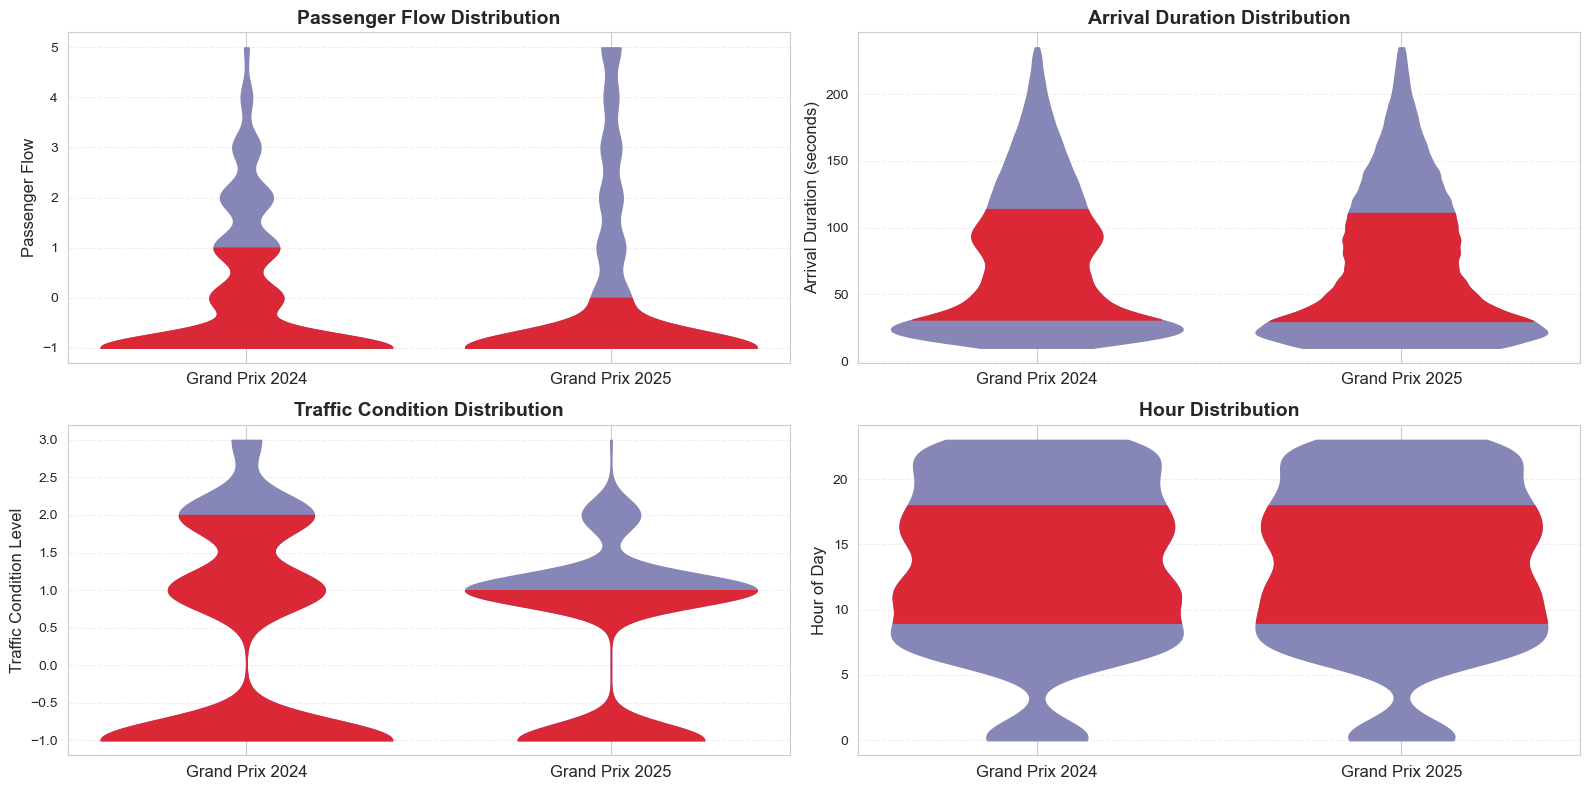

In [14]:
# Create violin plots using custom colors (solid colors, no legend)
print("\nGenerating violin plots for Grand Prix 2024 vs 2025 (solid colors, no legend)...")
fig, axes, output_file = create_multiple_violin_plots(
    df, 
    available_features, 
    output_dir,
    violin_rest_color=violin_rest_color,
    violin_q1_q3_color=violin_q1_q3_color
)

# Display the plot
plt.show()